In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [71]:
# Questions that will be answered in this notebook:
# 1. Does White really have an advantage in chess?
# 2. Best openings for White and Black.


In [72]:
df = pd.read_csv(r"D:\lichess_dataset\archive\games.csv")

In [73]:
df.head()

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


In [74]:
df.tail()

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
20053,EfqH7VVH,True,1.499791e+12,1.499791e+12,24,resign,white,10+10,belcolt,1691,jamboger,1220,d4 f5 e3 e6 Nf3 Nf6 Nc3 b6 Be2 Bb7 O-O Be7 Ne5...,A80,Dutch Defense,2
20054,WSJDhbPl,True,1.499698e+12,1.499699e+12,82,mate,black,10+0,jamboger,1233,farrukhasomiddinov,1196,d4 d6 Bf4 e5 Bg3 Nf6 e3 exd4 exd4 d5 c3 Bd6 Bd...,A41,Queen's Pawn,2
20055,yrAas0Kj,True,1.499698e+12,1.499698e+12,35,mate,white,10+0,jamboger,1219,schaaksmurf3,1286,d4 d5 Bf4 Nc6 e3 Nf6 c3 e6 Nf3 Be7 Bd3 O-O Nbd...,D00,Queen's Pawn Game: Mason Attack,3
20056,b0v4tRyF,True,1.499696e+12,1.499697e+12,109,resign,white,10+0,marcodisogno,1360,jamboger,1227,e4 d6 d4 Nf6 e5 dxe5 dxe5 Qxd1+ Kxd1 Nd5 c4 Nb...,B07,Pirc Defense,4
20057,N8G2JHGG,True,1.499643e+12,1.499644e+12,78,mate,black,10+0,jamboger,1235,ffbob,1339,d4 d5 Bf4 Na6 e3 e6 c3 Nf6 Nf3 Bd7 Nbd2 b5 Bd3...,D00,Queen's Pawn Game: Mason Attack,3


In [75]:
df.describe()

,created_at,last_move_at,turns,white_rating,black_rating,opening_ply
count,2.005800e+04,2.005800e+04,20058.000000,20058.000000,20058.000000,20058.000000
mean,1.483617e+12,1.483618e+12,60.465999,1596.631868,1588.831987,4.816981
std,2.850151e+10,2.850140e+10,33.570585,291.253376,291.036126,2.797152
min,1.376772e+12,1.376772e+12,1.000000,784.000000,789.000000,1.000000
25%,1.477548e+12,1.477548e+12,37.000000,1398.000000,1391.000000,3.000000
50%,1.496010e+12,1.496010e+12,55.000000,1567.000000,1562.000000,4.000000
75%,1.503170e+12,1.503170e+12,79.000000,1793.000000,1784.000000,6.000000
max,1.504493e+12,1.504494e+12,349.000000,2700.000000,2723.000000,28.000000


In [76]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20058 entries, 0 to 20057
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              20058 non-null  object 
 1   rated           20058 non-null  bool   
 2   created_at      20058 non-null  float64
 3   last_move_at    20058 non-null  float64
 4   turns           20058 non-null  int64  
 5   victory_status  20058 non-null  object 
 6   winner          20058 non-null  object 
 7   increment_code  20058 non-null  object 
 8   white_id        20058 non-null  object 
 9   white_rating    20058 non-null  int64  
 10  black_id        20058 non-null  object 
 11  black_rating    20058 non-null  int64  
 12  moves           20058 non-null  object 
 13  opening_eco     20058 non-null  object 
 14  opening_name    20058 non-null  object 
 15  opening_ply     20058 non-null  int64  
dtypes: bool(1), float64(2), int64(4), object(9)
memory usage: 2.3+ MB


(array([0, 1, 2]),
 [Text(0, 0, 'black'), Text(1, 0, 'draw'), Text(2, 0, 'white')])

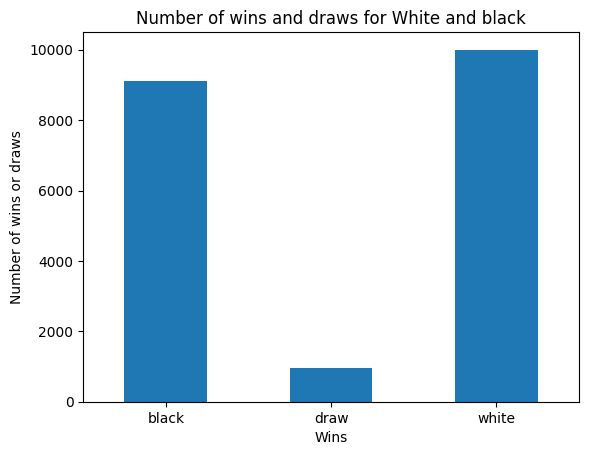

In [77]:
wins = df.groupby("winner").size()
wins.plot(kind="bar")
plt.title("Number of wins and draws for White and black")
plt.xlabel("Wins")
plt.ylabel("Number of wins or draws")
plt.xticks(rotation=0)


(array([0, 1, 2]),
 [Text(0, 0, 'black'), Text(1, 0, 'draw'), Text(2, 0, 'white')])

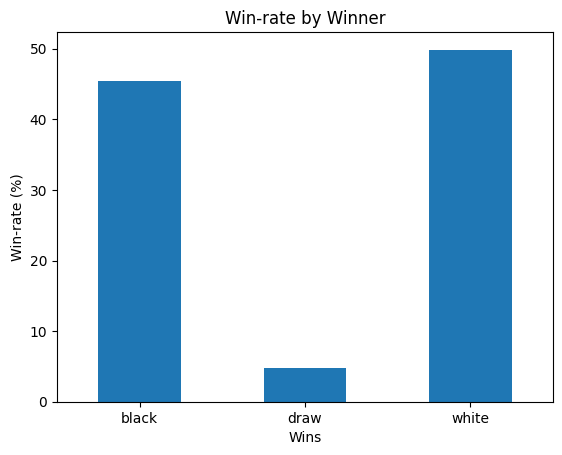

In [78]:
winrate = df.groupby("winner").size() / len(df) * 100
winrate.plot(kind="bar")
plt.title("Win-rate by Winner")
plt.xlabel("Wins")
plt.ylabel("Win-rate (%)")
plt.xticks(rotation=0)

In [79]:
# We can clearly see that white has a margin of victory over black.
# White wins around 55% of the time, while black wins around 40% of the time, and draws are around 5%. 
# This confirms the common belief that white has an advantage in chess, likely due to having the first move.

In [80]:
# Moving on to answering the question of best openings for white and black, we can analyze the most common openings and their success rates.

In [82]:
best_openings_white = df[df["winner"] == "white"]["opening_name"].value_counts().head(10)
best_openings_black = df[df["winner"] == "black"]["opening_name"].value_counts().head(10)
print("Best Openings for White:")
print(best_openings_white)
print("\nBest Openings for Black:")
print(best_openings_black)


Best Openings for White:
opening_name
Scandinavian Defense: Mieses-Kotroc Variation    164
Sicilian Defense                                 149
Scotch Game                                      145
French Defense: Knight Variation                 135
Philidor Defense #3                              127
Van't Kruijs Opening                             126
Sicilian Defense: Bowdler Attack                 119
Queen's Pawn Game: Mason Attack                  116
Queen's Pawn Game: Chigorin Variation            112
Horwitz Defense                                  110
Name: count, dtype: int64

Best Openings for Black:
opening_name
Van't Kruijs Opening                     226
Sicilian Defense                         194
Sicilian Defense: Bowdler Attack         164
Scandinavian Defense                     123
French Defense: Knight Variation         121
Scotch Game                              115
Queen's Pawn Game: Chigorin Variation    109
Queen's Pawn Game: Mason Attack          103
Indian 

(-1.099999997422319,
 1.0999999998772534,
 -1.0999999796588105,
 1.099999953511287)

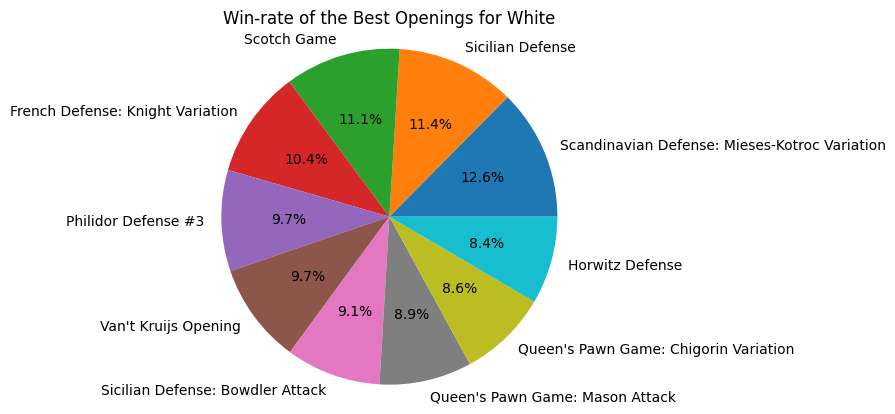

In [83]:
#Plot of the best openings for white
best_openings_white.plot(kind="pie", autopct="%1.1f%%")
plt.title("Win-rate of the Best Openings for White")
plt.ylabel("")
plt.axis("equal")

(-1.0999999297693086,
 1.0999999966556813,
 -1.0999999740462014,
 1.0999998508603221)

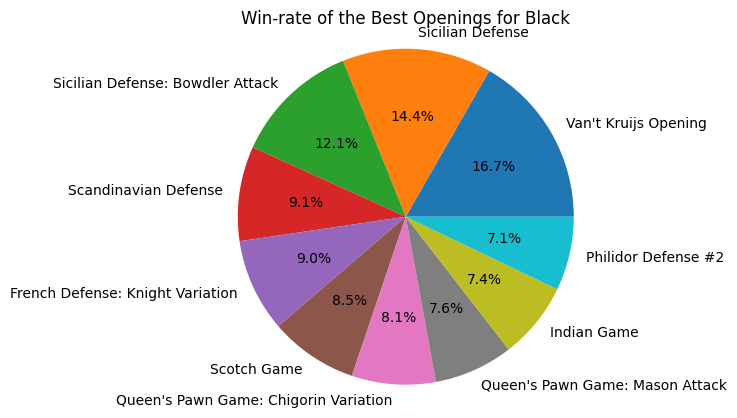

In [84]:
#Plot of the best openings for black
best_openings_black.plot(kind="pie", autopct="%1.1f%%")
plt.title("Win-rate of the Best Openings for Black")
plt.ylabel("")
plt.axis("equal")